In [3]:
import pandas as pd

df = pd.read_csv("Clean_Dataset.csv")

In [4]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Preprocessing

In [5]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['flight'])

df['class'] = df["class"].apply(lambda x: 1 if x == 'Business' else 0)
df.stops = pd.factorize(df.stops)[0]

In [7]:
df = pd.get_dummies(df, columns=['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city'])

In [8]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


## Training Regression Model

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, Y = df.drop(columns=['price']), df.price

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
reg = RandomForestRegressor(n_jobs= -1)

reg.fit(X_train, Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equ

In [12]:
reg.score(X_test, Y_test)

0.9849521662102472

In [13]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(X_test)

print('R2:', r2_score(Y_test, y_pred))
print('MAE:', mean_absolute_error(Y_test, y_pred))
print('MSE:', mean_squared_error(Y_test, y_pred))
print('RMSE:', math.sqrt(mean_squared_error(Y_test, y_pred)))

R2: 0.9849521662102472
MAE: 1076.505493536246
MSE: 7756891.574228297
RMSE: 2785.1196696422753


Text(0.5, 1.0, 'Prediction vs. Real Price')

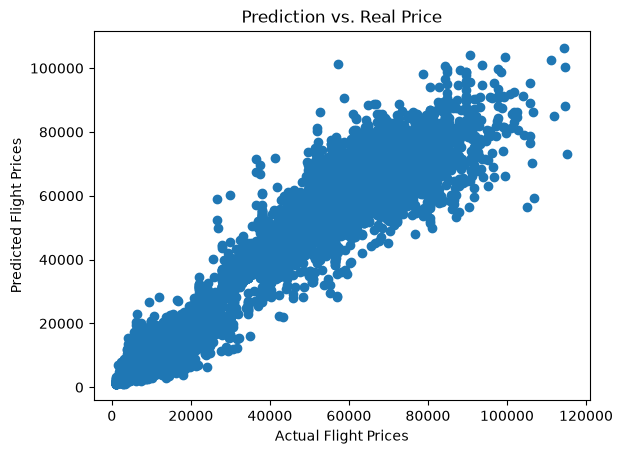

In [15]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, y_pred)
plt.xlabel('Actual Flight Prices')
plt.ylabel('Predicted Flight Prices')
plt.title('Prediction vs. Real Price')

In [17]:
importance = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

sorted_importance

[('class', np.float64(0.8798165313748626)),
 ('duration', np.float64(0.05777872327828284)),
 ('days_left', np.float64(0.018458477706421905)),
 ('airline_Vistara', np.float64(0.005400928868160724)),
 ('airline_Air_India', np.float64(0.004559551341872138)),
 ('source_city_Delhi', np.float64(0.003717829602962519)),
 ('destination_city_Delhi', np.float64(0.0034759894208209663)),
 ('source_city_Mumbai', np.float64(0.0022603465751715283)),
 ('stops', np.float64(0.0019099063817426857)),
 ('destination_city_Mumbai', np.float64(0.0019023801306984878)),
 ('destination_city_Kolkata', np.float64(0.0017753634367691092)),
 ('source_city_Kolkata', np.float64(0.0017371981997271132)),
 ('arrival_time_Evening', np.float64(0.0015342106651128743)),
 ('destination_city_Hyderabad', np.float64(0.0015156318511526825)),
 ('destination_city_Bangalore', np.float64(0.001320614092527945)),
 ('source_city_Hyderabad', np.float64(0.001238328939018887)),
 ('arrival_time_Night', np.float64(0.0011440773791198465)),
 ('s

<BarContainer object of 5 artists>

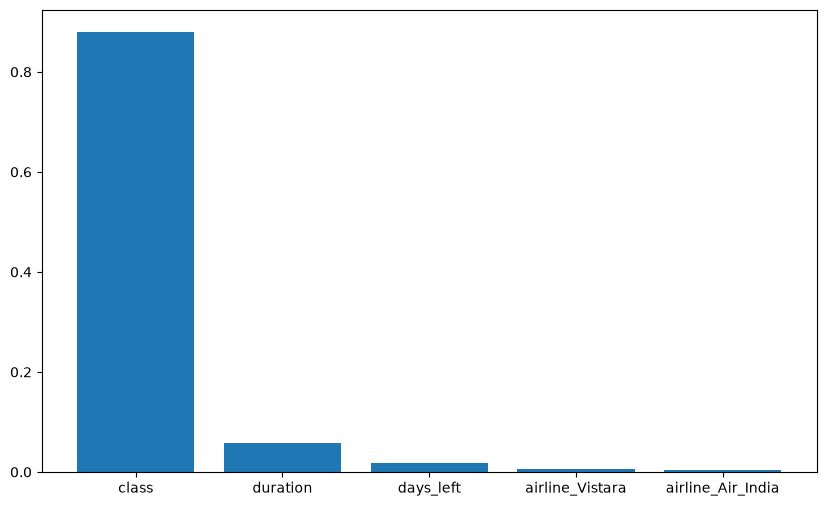

In [18]:
plt.figure(figsize=(10,6))
plt.bar([x[0] for x in sorted_importance[:5]], [x[1] for x in sorted_importance[:5]])

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

reg = RandomForestRegressor(n_jobs=-1)

pram_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': ['None', 10, 20, 30],
    'min_sample_split': [2, 5, 10],
    'min_sample_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

grid_search = GridSearchCV(reg, pram_grid, cv=5)
grid_search.fit(X_train, Y_train)

best_param = grid_search.best_params_

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pram_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': [1.0, 'sqrt']
}

reg = RandomForestRegressor(n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=pram_dist,
    n_iter=2,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=10,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=213; total time=   6.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=213; total time=   8.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=213; total time=   7.8s
[CV] END max_depth=30, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=257; total time=  49.2s
[CV] END max_depth=30, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=257; total time=  49.3s
[CV] END max_depth=30, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=257; total time=  44.6s


In [23]:
print(random_search.best_params_)
print(random_search.best_score_)

{'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 257}
-7402279.251766388
